# Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import svm
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score
import xgboost as xgb


# Data import and Exploration

In [2]:
#import dataset from UCI ML Repo
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
  
# metadata 
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata) 
  
# variable information 
print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [3]:
#combine the separated datasets into one for easier manipulation and cleaning
full_data = pd.concat([X, y], axis=1)
full_data.head(10)

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,Caucasian,Male,[50-60),NaN,2,1,2,3,NaN,NaN,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,Caucasian,Male,[60-70),NaN,3,1,2,4,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,Caucasian,Male,[70-80),NaN,1,1,7,5,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,>30
8,Caucasian,Female,[80-90),NaN,2,1,4,13,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,Caucasian,Female,[90-100),NaN,3,3,4,12,NaN,InternalMedicine,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
#convert to binary so I am only predicting >30 days readmission
#1 == <30 readmission, 0 == NO or >30 day readmission
full_data['readmitted'] = (full_data['readmitted'] == '<30').astype(int)

In [5]:
categorical_features = ['race', 'gender', 'max_glu_serum', '']

numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

target_var = ['readmitted']

In [6]:
full_data.columns

Index(['race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

In [7]:
full_data.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,0.111599
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,0.314874
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,0.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000


Text(0.5, 0, 'Admission Type ID')

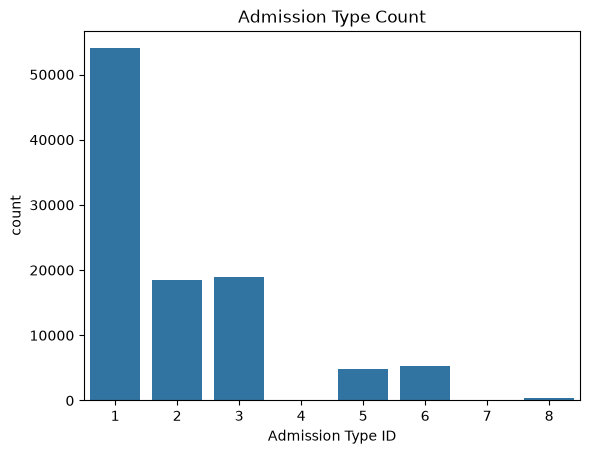

In [8]:
#observe distribution of admission type
admission_type_col = full_data['admission_type_id'].value_counts()

sns.barplot(data=admission_type_col)
plt.title('Admission Type Count')
plt.xlabel('Admission Type ID')

#Admission Type ID:
#- 1 = Emergency
#- 2 = Urgent
#- 3 = Elective
#- 4 = Newborn
#- 5 = N/A
#- 6 = NULL
#- 7 = Trauma Center
#- 8 =Not Mapped

Text(0.5, 0, 'Admission Source ID')

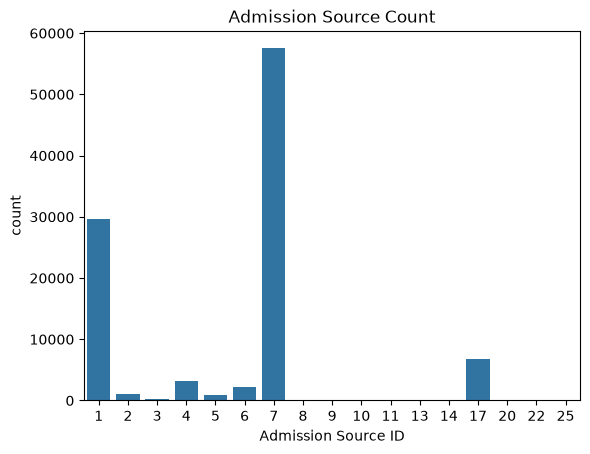

In [9]:
admission_source_col = X['admission_source_id'].value_counts()

sns.barplot(data=admission_source_col)
plt.title('Admission Source Count')
plt.xlabel('Admission Source ID')

#Most Prominent Admission Source ID:
#- 1 = Physician Referral
#- 7 = Emergency Room
#- 17 = Null 

Text(0.5, 1.0, 'Proportion of Patients on Diabetes Medication')

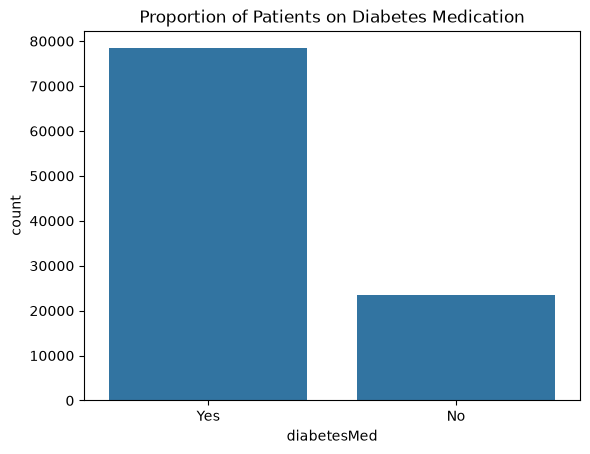

In [10]:
#distribution of patients on diabetes medication
count_onMed = X['diabetesMed'].value_counts(ascending=False)

sns.barplot(data=count_onMed)
plt.title('Proportion of Patients on Diabetes Medication')

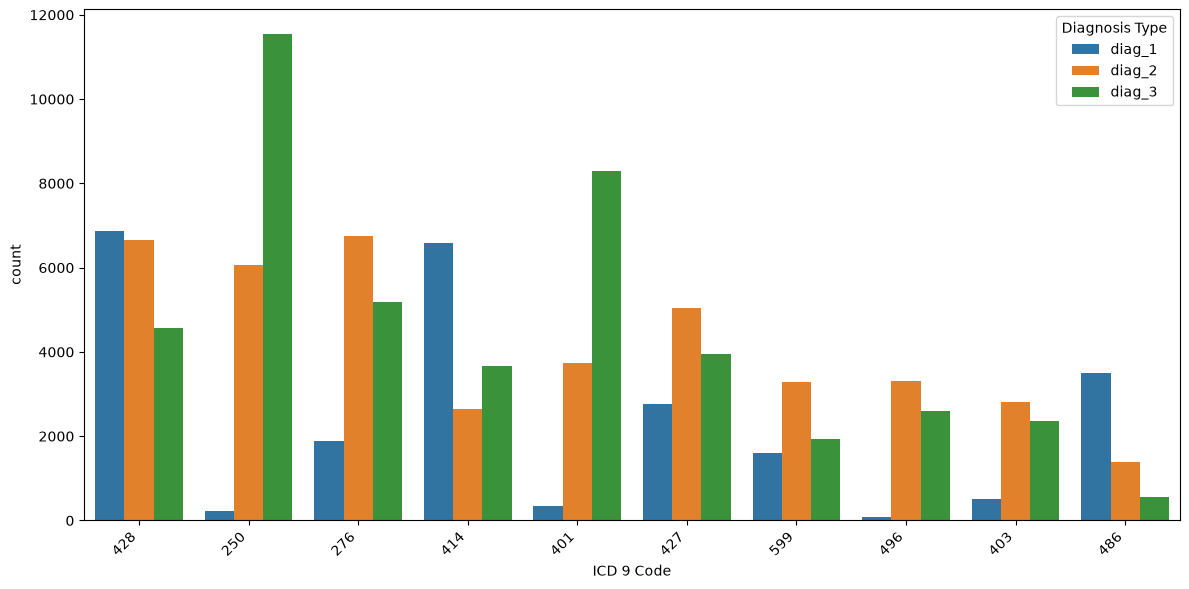

In [11]:
diag_long = pd.melt(
    full_data[['diag_1', 'diag_2', 'diag_3']],
    var_name='Diagnosis Type',
    value_name='ICD 9 Code'
)

plt.figure(figsize=(12, 6))
top_codes = diag_long['ICD 9 Code'].value_counts().head(10).index
sns.countplot(data=diag_long[diag_long['ICD 9 Code'].isin(top_codes)],
              x='ICD 9 Code', hue='Diagnosis Type',
              order=top_codes)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 428, 414, 401, 427, & 403 = Diseases of the circulatory system
# 250 & 276 = Endocrine, nutritional and metabolic diseases, and immunity disorders
# 599 = Diseases of the genitourinary system
# 496 & 486 = Diseases of the respiratory system
# The top 10 most frequently occurring diagnosis
# Most frequently occurring chapter of code is disease of the circulatory system (Heart disease) 

In [12]:
# Percentage of missing values per feature
missing_pct = (X.isnull().sum() / len(X)) * 100

# Filter and display only features with missing values
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(missing_pct.to_string())

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636


In [13]:
#remove weight, medical_specialty and payer code 
#because of the large amount of missing values
copy_df = full_data.drop(columns=['weight', 'medical_specialty', 'payer_code', 'max_glu_serum', 'A1Cresult'])
copy_df.head(10)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0
5,Caucasian,Male,[50-60),2,1,2,3,31,6,16,...,No,Steady,No,No,No,No,No,No,Yes,0
6,Caucasian,Male,[60-70),3,1,2,4,70,1,21,...,No,Steady,No,No,No,No,No,Ch,Yes,0
7,Caucasian,Male,[70-80),1,1,7,5,73,0,12,...,No,No,No,No,No,No,No,No,Yes,0
8,Caucasian,Female,[80-90),2,1,4,13,68,2,28,...,No,Steady,No,No,No,No,No,Ch,Yes,0
9,Caucasian,Female,[90-100),3,3,4,12,33,3,18,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [14]:
#age and gender are both later numerically mapped
categorical_features = ['race', 'gender', 'change', 'diabetesMed']

medicine_featuers = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 
                        'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
                        'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

In [15]:
#female == 0, male == 1
copy_df['gender'] = (copy_df['gender'] == 'Male').astype(int)

copy_df['change'] = (copy_df['change'] == 'Ch').astype(int) 

copy_df['diabetesMed'] = (copy_df['diabetesMed'] == 'No').astype(int)

age_mapping = {
    '[0-10)': 1,
    '[10-20)': 2,
    '[20-30)': 3,
    '[30-40)': 4,
    '[40-50)': 5,
    '[50-60)': 6,
    '[60-70)': 7,
    '[70-80)': 8,
    '[80-90)': 9,
    '[90-100)': 10
}

copy_df['age'] = copy_df['age'].map(age_mapping)

In [16]:
copy_df.shape

(101766, 43)

In [17]:
copy_df.isna().any(axis=None)

np.True_

# Research Questions

1. What machine learning classifier algorithm is best for predicting the readmission state (>30, <30, NO) for each diabetes patient?

2. Are there factors that are strongly correlated to a patient being readmitted? In the same context, are there factors that are correlated with patients not being readmitted?

3. Despite the significant amount of data missing for payer_code for patients, how does the type of insurance affect a patient's readmission state? Are they less likely to be readmitted if there insurance is private?

# Data Processing for ML

In [18]:
#copy data so that original dataset can be used later in project
ml_data = copy_df.copy()

#integer map the medicine features
med_mapping = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

for col in medicine_featuers:
    if col in ml_data.columns:
        ml_data[col] = ml_data[col].map(med_mapping)

ml_data = ml_data.drop(columns=['diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id','race'])

ml_data.head(10)

,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,0,1,1,41,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,0,2,3,59,0,18,0,0,0,9,...,0,3,0,0,0,0,0,1,0,0
2,0,3,2,11,5,13,2,0,1,6,...,0,0,0,0,0,0,0,0,0,0
3,1,4,2,44,1,16,0,0,0,7,...,0,3,0,0,0,0,0,1,0,0
4,1,5,1,51,0,8,0,0,0,5,...,0,1,0,0,0,0,0,1,0,0
5,1,6,3,31,6,16,0,0,0,9,...,0,1,0,0,0,0,0,0,0,0
6,1,7,4,70,1,21,0,0,0,7,...,0,1,0,0,0,0,0,1,0,0
7,1,8,5,73,0,12,0,0,0,8,...,0,0,0,0,0,0,0,0,0,0
8,0,9,13,68,2,28,0,0,0,8,...,0,1,0,0,0,0,0,1,0,0
9,0,10,12,33,3,18,0,0,0,8,...,0,1,0,0,0,0,0,1,0,0


In [19]:
#Isolate target variable
train_feat = ml_data.drop(columns=['readmitted'])
target = ml_data['readmitted']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(ml_data)
ml_data = pd.DataFrame(scaled_data, columns=ml_data.columns, index=ml_data.index)
ml_data.columns

#Split dataset so 20% is test, 80% is the remaining data
X_train_val, X_test, y_train_val, y_test = train_test_split(train_feat, target, test_size=0.2, random_state=42, stratify=target)

#Now split remaining dataset into validation and training set
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

In [20]:
print(f"Number of rows in training set: {len(X_train), len(y_train)}")
print(f"Number of rows in validation set: {len(X_val), len(y_val)}")
print(f"Number of rows in test set: {len(X_test), len(y_test)}")

Number of rows in training set: (61059, 61059)
Number of rows in validation set: (20353, 20353)
Number of rows in test set: (20354, 20354)


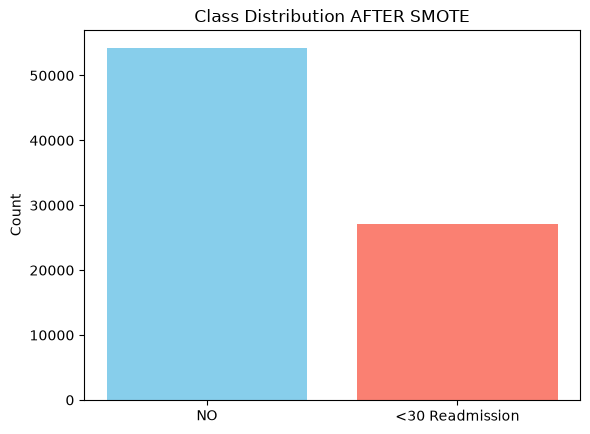

In [21]:
cat_cols = ['gender', 'age', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide','tolbutamide', 
            'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
            'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 
            'metformin-pioglitazone', 'change', 'diabetesMed']

categorical_features = [X_train.columns.get_loc(c) for c in cat_cols]

smote = SMOTENC(sampling_strategy=0.5, random_state=42, categorical_features=categorical_features)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['NO', '<30 Readmission'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

# 1. What machine learning classifier algorithm is best for predicting the readmission state (>30, <30, NO) for each diabetes patient?

The main goal of this research question is to try and build a meaningful model to predict the readmission state of a diabetic patient from the dataset. 

The plan is to start off with very generic prebuilt models, such as scikit-learn logistic regression, Decision Trees, etc., and end with building my own model. I expect to have to build a my own model because the generic models will not be tuned enough to accurately predict the dataset.

### Logistic Regression

In [22]:
readmitted_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42, class_weight='balanced')
readmitted_pred_LogR.fit(X_train, y_train)

pred_train_LogR = readmitted_pred_LogR.predict(X_train)
pred_val_LogR = readmitted_pred_LogR.predict(X_val)
#pred_test_logR = readmitted_pred_LogR.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_LogR)}")
print(f"Testing accuracy: {accuracy_score(y_val, pred_val_LogR)}")
#print(f"Testing accuracy: {accuracy_score(y_test, pred_test_logR)}")

Training accuracy: 0.6746753140405182
Testing accuracy: 0.6748882228664079


In [23]:
logR_matrix = confusion_matrix(pred_val_LogR, y_val)
print(logR_matrix)

[[12624  1159]
 [ 5458  1112]]


Confusion matrix, without normalization
[[12605  5478]
 [ 1122  1149]]
Normalized confusion matrix
[[0.69706354 0.30293646]
 [0.49405548 0.50594452]]


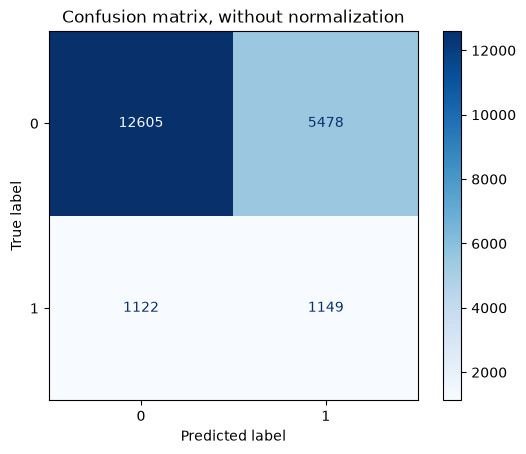

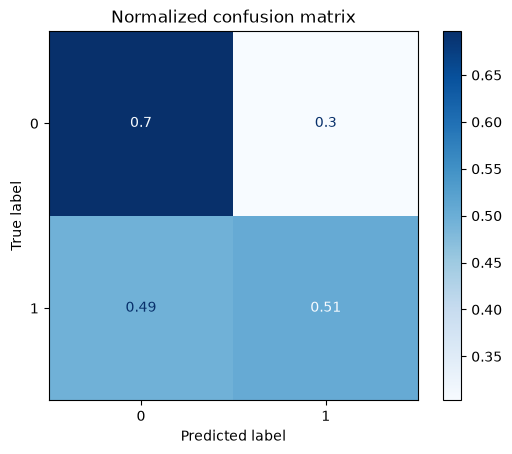

In [24]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_LogR,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

In [ ]:
readmitted_pred_LogR_SMOTE = LogisticRegression(max_iter = 5000, random_state= 42)
readmitted_pred_LogR_SMOTE.fit(X_train_sm, y_train_sm)

pred_train_LogR_SMOTE = readmitted_pred_LogR_SMOTE.predict(X_train)
#pred_test_logR_SMOTE = readmitted_pred_LogR_SMOTE.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_LogR_SMOTE)}")
#print(f"Testing accuracy: {accuracy_score(y_test, pred_test_logR_SMOTE)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_LogR_SMOTE,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29

### Decision Tree Classifier

In [ ]:
readmitted_pred_DT = DecisionTreeClassifier(max_leaf_nodes=len(X.columns), random_state= 42)
readmitted_pred_DT.fit(X_train, y_train)

pred_train_DT = readmitted_pred_DT.predict(X_train)
pred_val_DT = readmitted_pred_DT.predict(X_val)
pred_test_DT = readmitted_pred_DT.predict(X_test)

print(f"Decision Tree Training accuracy: {accuracy_score(y_train, pred_train_DT)}")
print(f"Decision Tree Validation accuracy: {accuracy_score(y_val, pred_val_DT)}")
print(f"Decistion Tree Testing accuracy: {accuracy_score(y_test, pred_test_DT)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_DT,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

In [ ]:
readmitted_pred_DT_SMOTE = DecisionTreeClassifier(max_leaf_nodes=len(X.columns), random_state= 42)
readmitted_pred_DT_SMOTE.fit(X_train_sm, y_train_sm)

pred_train_DT_SMOTE = readmitted_pred_DT_SMOTE.predict(X_train)
pred_test_DT_SMOTE = readmitted_pred_DT_SMOTE.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_DT_SMOTE)}")
print(f"Testing accuracy: {accuracy_score(y_test, pred_test_DT_SMOTE)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_DT_SMOTE,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

### SVM Classifier 

In [ ]:
readmitted_pred_SVM = svm.SVC(kernel='rbf', C=2, random_state=42)
readmitted_pred_SVM.fit(X_train, y_train)

pred_train_SVM = readmitted_pred_SVM.predict(X_train)
pred_val_SVM = readmitted_pred_SVM.predict(X_val)
pred_test_SVM = readmitted_pred_SVM.predict(X_test)


print(f"SVM RBF CLF Training accuracy: {accuracy_score(y_train, pred_train_SVM)}")
print(f"SVM RBF CLF Validation accuracy: {accuracy_score(y_val, pred_val_SVM)}")
print(f"SVM RBF CLF Testing accuracy: {accuracy_score(y_test, pred_test_SVM)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_SVM,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

In [ ]:
readmitted_pred_SVM_SMOTE = svm.SVC(kernel='rbf', C=2, random_state=42)
readmitted_pred_SVM_SMOTE.fit(X_train_sm, y_train_sm)

pred_train_SVM_SMOTE = readmitted_pred_SVM_SMOTE.predict(X_train)
pred_val_SVM_SMOTE = readmitted_pred_SVM_SMOTE.predict(X_val)
pred_test_SVM_SMOTE = readmitted_pred_SVM_SMOTE.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_SVM_SMOTE)}")
print(f"Testing accuracy: {accuracy_score(y_test, pred_test_SVM_SMOTE)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_SVM_SMOTE,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

### Random Forest Classifier

In [ ]:
readmitted_pred_RF = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
readmitted_pred_RF.fit(X_train, y_train)

pred_train_RF = readmitted_pred_RF.predict(X_train)
pred_val_RF = readmitted_pred_RF.predict(X_val)
pred_test_RF = readmitted_pred_RF.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_RF)}")
print(f"Validation accuracy: {accuracy_score(y_val, pred_val_RF)}")
print(f"Testing accuracy: {accuracy_score(y_test, pred_test_RF)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_RF,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

In [ ]:
readmitted_pred_RF_SMOTE = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
readmitted_pred_RF_SMOTE.fit(X_train_sm, y_train_sm)

pred_train_RF_SMOTE = readmitted_pred_RF_SMOTE.predict(X_train)
pred_val_RF_SMOTE = readmitted_pred_RF_SMOTE.predict(X_val)
pred_test_RF_SMOTE = readmitted_pred_RF_SMOTE.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_RF_SMOTE)}")
print(f"Validation accuracy: {accuracy_score(y_val, pred_val_RF_SMOTE)}")
print(f"Testing accuracy: {accuracy_score(y_test, pred_test_RF_SMOTE)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_RF_SMOTE,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

### XGBoost 

In [27]:
readmitted_xgb = xgb.XGBClassifier(random_state=42, device="cuda")

readmitted_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

pred_train_XGB = readmitted_xgb.predict(X_train)
pred_val_XGB = readmitted_xgb.predict(X_val)
#pred_test_XGB = readmitted_xgb.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_XGB)}")
print(f"Validation accuracy: {accuracy_score(y_val, pred_val_XGB)}")
#print(f"Testing accuracy: {accuracy_score(y_test, pred_test_XGB)}")
print("\nConfusion Matrix:\n", confusion_matrix(y_val, pred_val_XGB))

c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:20:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:20:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Training accuracy: 0.8938731390949737
Validation accuracy: 0.8874367415123078

Confusion Matrix:
 [[18024    58]
 [ 2233    38]]


In [ ]:
#tune hyperparameters of model trained on standard dataset
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10, 100],
    'reg_lambda': [0.5, 0.7, 1, 1.3]
}

grid_search = RandomizedSearchCV(readmitted_xgb, param_grid, cv=10, scoring="accuracy", n_iter=200, n_jobs=-1, verbose=2, random_state=42)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_

best_xgb_pred = best_xgb.predict(X_test)

best_cm = confusion_matrix(y_test, best_xgb_pred)

# Best parameters from tuning
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)
print("Confusion Matrix:", best_cm)

Fitting 10 folds for each of 200 candidates, totalling 2000 fits


c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:25:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:25:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 1.0, 'reg_lambda': 0.7, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best Accuracy: 0.8888124649081085
Confusion Matrix: [[18069    14]
 [ 2256    15]]


In [26]:
readmitted_xgb = xgb.XGBClassifier(random_state=42, device="cuda")

readmitted_xgb.fit(X_train_sm, y_train_sm, eval_set=[(X_test, y_test)], verbose=False)

pred_train_XGB_sm = readmitted_xgb.predict(X_train)
pred_val_XGB_sm = readmitted_xgb.predict(X_val)
#pred_test_XGB_sm = readmitted_xgb.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_XGB_sm)}")
print(f"Validation accuracy: {accuracy_score(y_val, pred_val_XGB_sm)}")
#print(f"Testing accuracy: {accuracy_score(y_test, pred_test_XGB)}")
print("\nConfusion Matrix:\n", confusion_matrix(y_val, pred_val_XGB_sm))

c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:16:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:16:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Training accuracy: 0.8709444963068508
Validation accuracy: 0.8579079251216037

Confusion Matrix:
 [[17247   835]
 [ 2057   214]]


In [ ]:
#tune hyperparameters of model trained on SMOTE dataset
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10, 100],
    'reg_lambda': [0.5, 0.7, 1, 1.3]
}

grid_search = RandomizedSearchCV(readmitted_xgb, param_grid, cv=10, scoring="accuracy", n_iter=200, n_jobs=-1, verbose=2, random_state=42)
grid_search.fit(X_train_sm, y_train_sm)

best_xgb_sm = grid_search.best_estimator_

best_xgb_pred_sm = best_xgb_sm.predict(X_test)

best_cm_sm = confusion_matrix(y_test, best_xgb_pred_sm)

# Best parameters from tuning
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)
print("Confusion Matrix:", best_cm_sm)

Fitting 10 folds for each of 200 candidates, totalling 2000 fits


c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:33:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:33:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 0.85}
Best Accuracy: 0.8635819313044836
Confusion Matrix: [[18069    14]
 [ 2256    15]]


# Model Comparison

In [ ]:
#Logistic Regression Performance w/ and w/o SMOTE
accuracy = accuracy_score(y_test, pred_test_logR)
print(f"LogR Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_logR))

accuracy = accuracy_score(y_test, pred_test_logR_SMOTE)
print(f"LogR Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_logR_SMOTE))


In [ ]:
#Decisiion Tree Performance w/ and w/o SMOTE
accuracy = accuracy_score(y_test, pred_test_DT)
print(f"DT Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_DT))

accuracy = accuracy_score(y_test, pred_test_DT_SMOTE)
print(f"DT Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_DT_SMOTE))

In [ ]:
#SVM Classifier Performance w/ and w/o SMOTE
accuracy = accuracy_score(y_test, pred_test_SVM)
print(f"SVM Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_SVM))

accuracy = accuracy_score(y_test, pred_test_SVM_SMOTE)
print(f"SVM Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_SVM_SMOTE))

In [ ]:
#Random Forest Performance w/ and w/o SMOTE
accuracy = accuracy_score(y_test, pred_test_RF)
print(f"RF Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_RF_SMOTE))

accuracy = accuracy_score(y_test, pred_test_RF_SMOTE)
print(f"RF Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_RF_SMOTE))

### Area Under the Receiver Operating Characteristic curve (AUROC)

In [ ]:
#AUROC graphs
fig, ax = plt.subplots(1,2, figsize = (15,5))
RocCurveDisplay.from_estimator(readmitted_pred_LogR, X_test, y_test, ax=ax[0], name="LogReg")
RocCurveDisplay.from_estimator(readmitted_pred_DT, X_test, y_test, ax=ax[0], name="DT")
RocCurveDisplay.from_estimator(readmitted_pred_SVM, X_test, y_test, ax=ax[0], name="SVM")
RocCurveDisplay.from_estimator(readmitted_pred_RF, X_test, y_test, ax=ax[0], name="RF")

RocCurveDisplay.from_estimator(readmitted_pred_LogR_SMOTE, X_test, y_test, ax=ax[1], name="LogRegSMOTE")
RocCurveDisplay.from_estimator(readmitted_pred_DT_SMOTE, X_test, y_test, ax=ax[1], name="DTSMOTE")
RocCurveDisplay.from_estimator(readmitted_pred_SVM_SMOTE, X_test, y_test, ax=ax[1], name="SVMSMOTE")
RocCurveDisplay.from_estimator(readmitted_pred_RF_SMOTE, X_test, y_test, ax=ax[1], name="RFSMOTE")

plt.show()

### Area Under the Precision-Recall Curve (AUPRC)

In [ ]:
#AUPRC Graphs
model_groups = {
    "Logistic Regression": {
        "Original": readmitted_pred_LogR,
        "SMOTE": readmitted_pred_LogR_SMOTE,
    },
    "Decision Tree": {
        "Original": readmitted_pred_DT,
        "SMOTE": readmitted_pred_DT_SMOTE,
    },
    "Random Forest": {
        "Original": readmitted_pred_RF,
        "SMOTE": readmitted_pred_RF_SMOTE,
    },
}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
axes = axes.ravel()  # flatten 2x2 grid into a list of 4 for easy indexing

for ax, (algo_name, variants) in zip(axes, model_groups.items()):
    for label, model in variants.items():
        y_prob = model.predict_proba(X_val)[:, 1]  # always score on validation, both variants
        precision, recall, _ = precision_recall_curve(y_val, y_prob)
        ap = average_precision_score(y_val, y_prob)
        ax.plot(recall, precision, label=f"{label} (AP={ap:.3f})")

    ax.set_title(algo_name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Stratified Analysis Across Race
Stratified analysis for comparing model performance on differenct races.

In [32]:
copy_df['race'].unique()

<StringArray>
['Caucasian', 'AfricanAmerican', nan, 'Other', 'Asian', 'Hispanic']
Length: 6, dtype: str

In [33]:
race_data = copy_df.copy()

#apply map to medication columns
med_mapping = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

for col in medicine_featuers:
    if col in race_data.columns:
        race_data[col] = race_data[col].map(med_mapping)

race_data = race_data.drop(columns=['diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id'])

asian_data = race_data[race_data['race'] == 'Asian']
caucasian_data = race_data[race_data['race'] == 'Caucasian']
africanamerican_data = race_data[race_data['race'] == 'AfricanAmerican']
hispanic_data = race_data[race_data['race'] == 'Hispanic']
other_data = race_data[race_data['race'] == 'Other']


### Asian Data

In [34]:
#split data
asian_train_feat = asian_data.drop(columns=['readmitted', 'race'])
asian_target = asian_data['readmitted']

#Split dataset so 20% is test, 80% is the remaining data
X_train_val_asian, X_test_asian, y_train_val_asian, y_test_asian = train_test_split(asian_train_feat, asian_target, test_size=0.2, random_state=42, stratify=asian_target)

#Now split remaining dataset into validation and training set
X_train_asian, X_val_asian, y_train_asian, y_val_asian = train_test_split(X_train_val_asian, y_train_val_asian, test_size=0.25, random_state=42, stratify=y_train_val_asian)

In [35]:
asian_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42, class_weight='balanced')
asian_pred_LogR.fit(X_train_asian, y_train_asian)

asian_pred_train_LogR = asian_pred_LogR.predict(X_train_asian)
asian_pred_val_LogR = asian_pred_LogR.predict(X_val_asian)
asian_pred_test_logR = asian_pred_LogR.predict(X_test_asian)

print(f"Training accuracy on Asian set: {accuracy_score(y_train_asian, asian_pred_train_LogR)}")
print(f"Validation accuracy on Asian set: {accuracy_score(y_val_asian, asian_pred_val_LogR)}")
print(f"Testing accuracy on Asian set: {accuracy_score(y_test_asian, asian_pred_test_logR)}")

Training accuracy on Asian set: 0.640625
Validation accuracy on Asian set: 0.6875
Testing accuracy on Asian set: 0.627906976744186


Confusion matrix, without normalization
[[11097  6986]
 [ 1127  1144]]
Normalized confusion matrix
[[0.6136703  0.3863297 ]
 [0.49625716 0.50374284]]


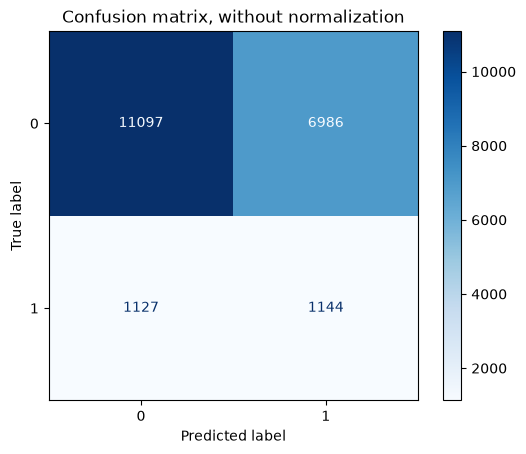

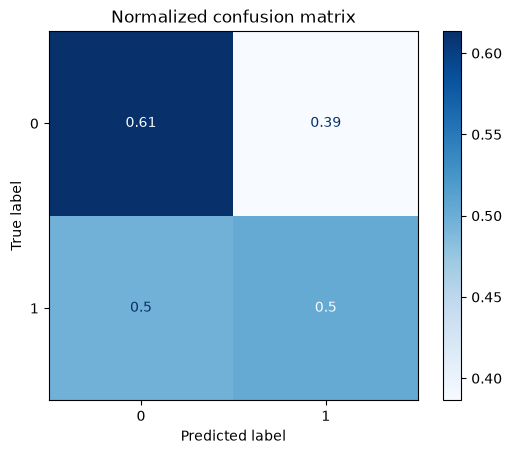

In [36]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        asian_pred_LogR,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29

### Caucasian Data  

In [38]:
#split data
caucasian_train_feat = caucasian_data.drop(columns=['readmitted', 'race'])
caucasian_target = caucasian_data['readmitted']

#Split dataset so 20% is test, 80% is the remaining data
X_train_val_caucasian, X_test_caucasian, y_train_val_caucasian, y_test_caucasian = train_test_split(caucasian_train_feat, caucasian_target, test_size=0.2, random_state=42, stratify=caucasian_target)

#Now split remaining dataset into validation and training set
X_train_caucasian, X_val_caucasian, y_train_caucasian, y_val_caucasian = train_test_split(X_train_val_caucasian, y_train_val_caucasian, test_size=0.25, random_state=42, stratify=y_train_val_caucasian)

In [39]:
caucasian_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42, class_weight='balanced')
caucasian_pred_LogR.fit(X_train_asian, y_train_asian)

caucasian_pred_train_LogR = caucasian_pred_LogR.predict(X_train_caucasian)
caucasian_pred_val_LogR = caucasian_pred_LogR.predict(X_val_caucasian)
caucasian_pred_test_logR = caucasian_pred_LogR.predict(X_test_caucasian)

print(f"Training accuracy on caucasian set: {accuracy_score(y_train_caucasian, caucasian_pred_train_LogR)}")
print(f"Validation accuracy on caucasian set: {accuracy_score(y_val_caucasian, caucasian_pred_val_LogR)}")
print(f"Testing accuracy on caucasian set: {accuracy_score(y_test_caucasian, caucasian_pred_test_logR)}")

Training accuracy on caucasian set: 0.5751111500470882
Validation accuracy on caucasian set: 0.5763469119579501
Testing accuracy on caucasian set: 0.5716819973718791


Confusion matrix, without normalization
[[11097  6986]
 [ 1127  1144]]
Normalized confusion matrix
[[0.6136703  0.3863297 ]
 [0.49625716 0.50374284]]


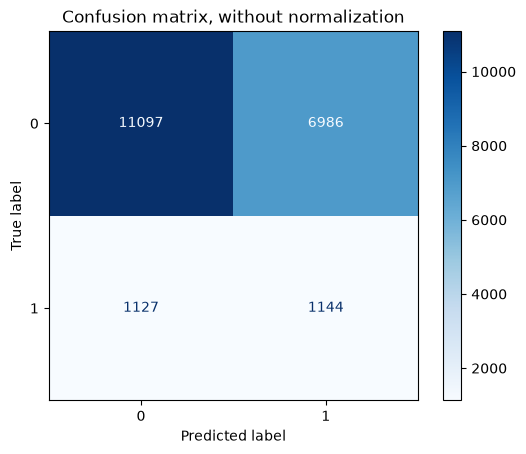

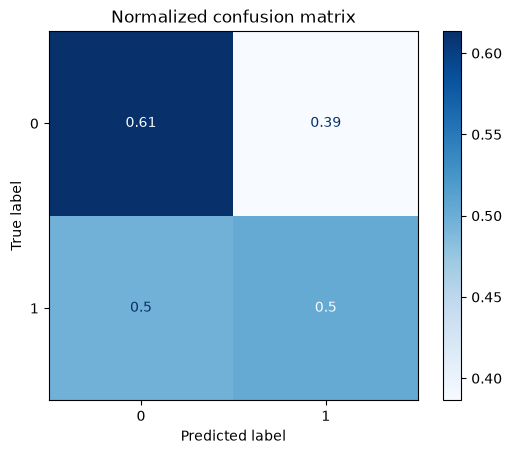

In [40]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        caucasian_pred_LogR,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29

### African American Data

In [41]:
#split data
africanamerican_train_feat = africanamerican_data.drop(columns=['readmitted', 'race'])
africanamerican_target = africanamerican_data['readmitted']

#Split dataset so 20% is test, 80% is the remaining data
X_train_val_africanamerican, X_test_africanamerican, y_train_val_africanamerican, y_test_africanamerican = train_test_split(africanamerican_train_feat, africanamerican_target, test_size=0.2, random_state=42, stratify=africanamerican_target)

#Now split remaining dataset into validation and training set
X_train_africanamerican, X_val_africanamerican, y_train_africanamerican, y_val_africanamerican = train_test_split(X_train_val_africanamerican, y_train_val_africanamerican, test_size=0.25, random_state=42, stratify=y_train_val_africanamerican)

In [42]:
africanamerican_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42, class_weight='balanced')
africanamerican_pred_LogR.fit(X_train_asian, y_train_asian)

africanamerican_pred_train_LogR = africanamerican_pred_LogR.predict(X_train_africanamerican)
africanamerican_pred_val_LogR = africanamerican_pred_LogR.predict(X_val_africanamerican)
africanamerican_pred_test_logR = africanamerican_pred_LogR.predict(X_test_africanamerican)

print(f"Training accuracy on african american set: {accuracy_score(y_train_africanamerican, africanamerican_pred_train_LogR)}")
print(f"Validation accuracy on african american set: {accuracy_score(y_val_africanamerican, africanamerican_pred_val_LogR)}")
print(f"Testing accuracy on african american set: {accuracy_score(y_test_africanamerican, africanamerican_pred_test_logR)}")

Training accuracy on african american set: 0.6673607496095784
Validation accuracy on african american set: 0.6759500260281104
Testing accuracy on african american set: 0.6592920353982301


Confusion matrix, without normalization
[[11097  6986]
 [ 1127  1144]]
Normalized confusion matrix
[[0.6136703  0.3863297 ]
 [0.49625716 0.50374284]]


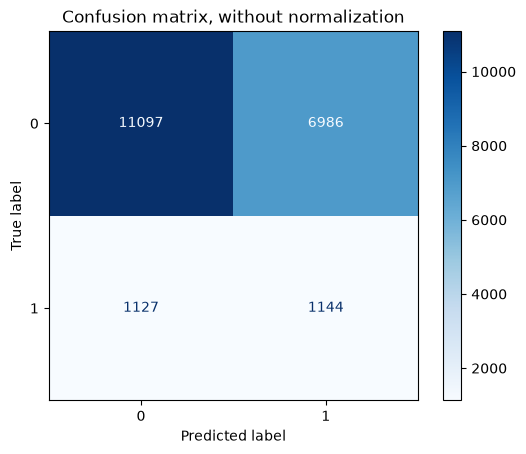

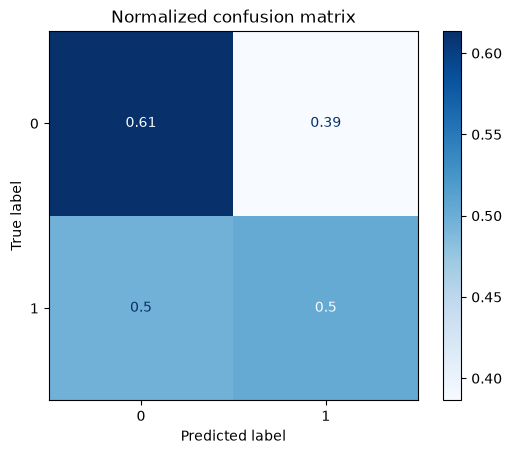

In [43]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        africanamerican_pred_LogR,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29

### Hispanic Data 

In [44]:
#split data
hispanic_train_feat = hispanic_data.drop(columns=['readmitted', 'race'])
hispanic_target = hispanic_data['readmitted']

#Split dataset so 20% is test, 80% is the remaining data
X_train_val_hispanic, X_test_hispanic, y_train_val_hispanic, y_test_hispanic = train_test_split(hispanic_train_feat, hispanic_target, test_size=0.2, random_state=42, stratify=hispanic_target)

#Now split remaining dataset into validation and training set
X_train_hispanic, X_val_hispanic, y_train_hispanic, y_val_hispanic = train_test_split(X_train_val_hispanic, y_train_val_hispanic, test_size=0.25, random_state=42, stratify=y_train_val_hispanic)

In [47]:
hispanic_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42, class_weight='balanced')
hispanic_pred_LogR.fit(X_train_hispanic, y_train_hispanic)

hispanic_pred_train_LogR = hispanic_pred_LogR.predict(X_train_hispanic)
hispanic_pred_val_LogR = hispanic_pred_LogR.predict(X_val_hispanic)
hispanic_pred_test_logR = hispanic_pred_LogR.predict(X_test_hispanic)

print(f"Training accuracy on hispanic set: {accuracy_score(y_train_hispanic, hispanic_pred_train_LogR)}")
print(f"Validation accuracy on hispanic set: {accuracy_score(y_val_hispanic, hispanic_pred_val_LogR)}")
print(f"Testing accuracy on hispanic set: {accuracy_score(y_test_hispanic, hispanic_pred_test_logR)}")

Training accuracy on hispanic set: 0.6904176904176904
Validation accuracy on hispanic set: 0.6617647058823529
Testing accuracy on hispanic set: 0.6200980392156863


Confusion matrix, without normalization
[[10159  7924]
 [  935  1336]]
Normalized confusion matrix
[[0.56179837 0.43820163]
 [0.4117129  0.5882871 ]]


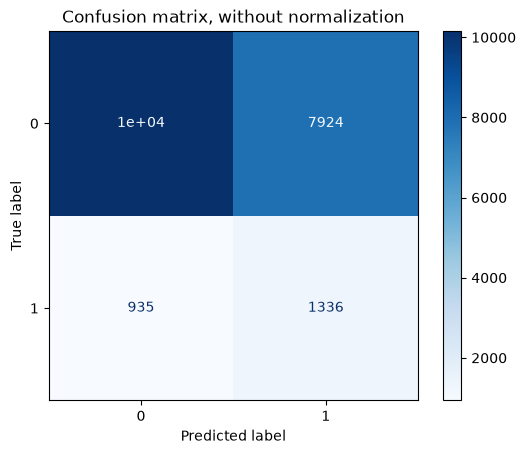

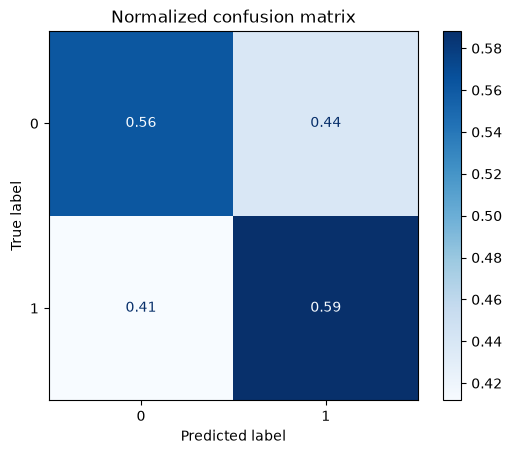

In [48]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        hispanic_pred_LogR,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29

### Other Race Data

In [49]:
#split data
other_train_feat = other_data.drop(columns=['readmitted', 'race'])
other_target = other_data['readmitted']

#Split dataset so 20% is test, 80% is the remaining data
X_train_val_other, X_test_other, y_train_val_other, y_test_other = train_test_split(other_train_feat, other_target, test_size=0.2, random_state=42, stratify=other_target)

#Now split remaining dataset into validation and training set
X_train_other, X_val_other, y_train_other, y_val_other = train_test_split(X_train_val_other, y_train_val_other, test_size=0.25, random_state=42, stratify=y_train_val_other)

In [53]:
other_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42, class_weight='balanced')
other_pred_LogR.fit(X_train_other, y_train_other)

other_train_LogR = other_pred_LogR.predict(X_train_other)
other_val_LogR = other_pred_LogR.predict(X_val_other)
other_test_LogR = other_pred_LogR.predict(X_test_other)

print(f"Training accuracy on other set: {accuracy_score(y_train_other, other_train_LogR)}")
print(f"Validation accuracy on other set: {accuracy_score(y_val_other, other_val_LogR)}")
print(f"Testing accuracy on other set: {accuracy_score(y_test_other, other_test_LogR)}")

Training accuracy on other set: 0.64562569213732
Validation accuracy on other set: 0.6245847176079734
Testing accuracy on other set: 0.6788079470198676


Confusion matrix, without normalization
[[11232  6851]
 [ 1104  1167]]
Normalized confusion matrix
[[0.62113587 0.37886413]
 [0.48612946 0.51387054]]


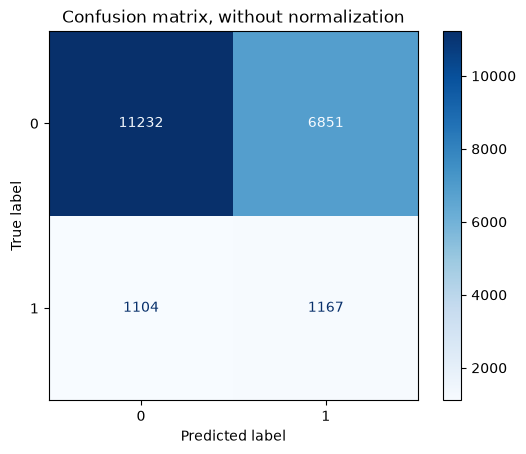

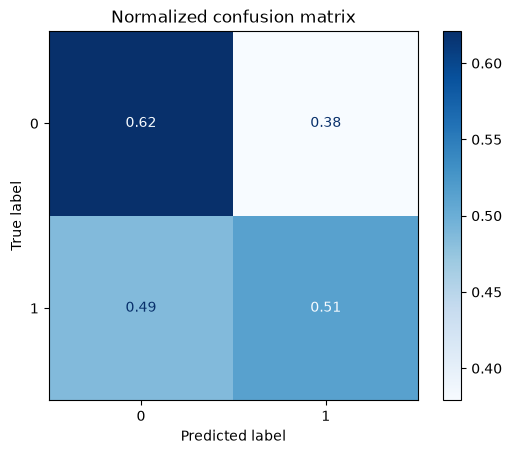

In [54]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        other_pred_LogR,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29